Amostras que já temos: 12 poços
GP treinado. Kernel aprendido: 3.36**2 * RBF(length_scale=1.9) + WhiteKernel(noise_level=0.314)


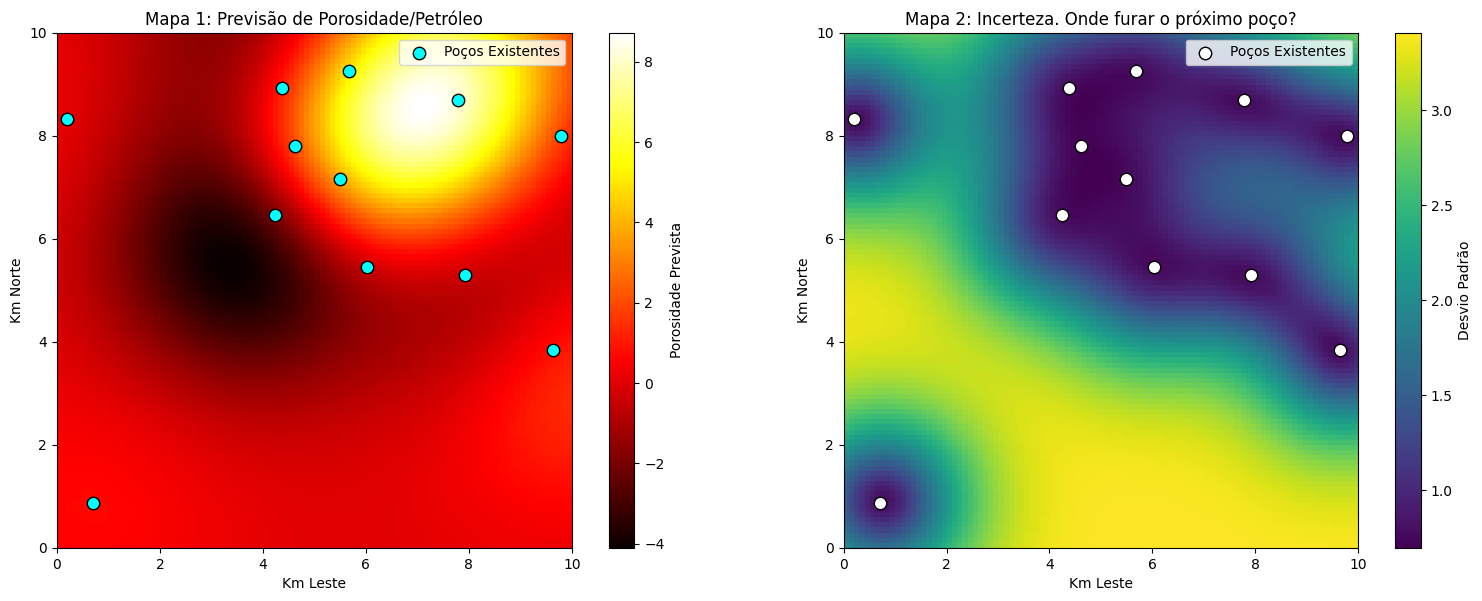


Recomendação GP: Fure o próximo poço em X=7.07km, Y=8.48km


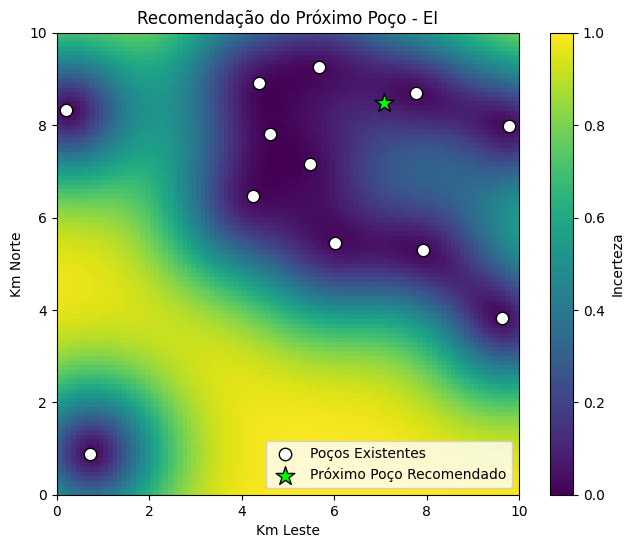

In [1]:

# 0. INSTALAR E IMPORTAR
!pip install scikit-learn matplotlib numpy -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

np.random.seed(0)

# 1. FUNÇÃO DO CAMPO - SIMULAÇÃO DO TERRENO REAL
# No mundo real isso são os dados dos 12 poços já furados
def funcao_petroleo_real(x, y):
    """Retorna a porosidade real em um ponto x,y. Tem 3 bolsões."""
    return 10 * np.exp(-((x-2)**2 + (y-3)**2)/4) + \
           15 * np.exp(-((x-7)**2 + (y-8)**2)/2) + \
           8  * np.exp(-((x-5)**2 + (y-2)**2)/3)

# 2. DADOS DE TREINO: OS 12 POÇOS QUE JÁ FURAMOS
X_train = np.random.rand(12, 2) * 10  # Coordenadas X,Y de 0 a 10km
y_train = funcao_petroleo_real(X_train[:, 0], X_train[:, 1]) + np.random.normal(0, 1, 12)

print(f"Amostras que já temos: {len(X_train)} poços")

# 3. TREINAR O PROCESSO GAUSSIANO
# Kernel: RBF = suavidade, WhiteKernel = ruído de medição
kernel = C(10, (1e-1, 1e3)) * RBF(2, (0.1, 10)) + WhiteKernel(1, (1e-2, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, random_state=0)

gp.fit(X_train, y_train)
print("GP treinado. Kernel aprendido:", gp.kernel_)

# 4. CRIAR GRID PARA PREVER O CAMPO TODO
x_grid = np.linspace(0, 10, 100)
y_grid = np.linspace(0, 10, 100)
X1, X2 = np.meshgrid(x_grid, y_grid)
X_pred = np.vstack([X1.ravel(), X2.ravel()]).T

y_pred, sigma = gp.predict(X_pred, return_std=True)
y_pred = y_pred.reshape(100, 100)
sigma = sigma.reshape(100, 100)

# 5. PLOTAR MAPA DE PREVISÃO E MAPA DE INCERTEZA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# MAPA 1: PREVISÃO
im1 = ax1.imshow(y_pred, extent=(0, 10, 0, 10), origin='lower', cmap='hot')
ax1.scatter(X_train[:, 0], X_train[:, 1], c='cyan', s=80, edgecolor='black', label='Poços Existentes')
ax1.set_title('Mapa 1: Previsão de Porosidade/Petróleo')
ax1.set_xlabel('Km Leste')
ax1.set_ylabel('Km Norte')
ax1.legend()
fig.colorbar(im1, ax=ax1, label='Porosidade Prevista')

# MAPA 2: INCERTEZA
im2 = ax2.imshow(sigma, extent=(0, 10, 0, 10), origin='lower', cmap='viridis')
ax2.scatter(X_train[:, 0], X_train[:, 1], c='white', s=80, edgecolor='black', label='Poços Existentes')
ax2.set_title('Mapa 2: Incerteza. Onde furar o próximo poço?')
ax2.set_xlabel('Km Leste')
ax2.set_ylabel('Km Norte')
ax2.legend()
fig.colorbar(im2, ax=ax2, label='Desvio Padrão')
plt.tight_layout()
plt.show()

# 6. RECOMENDAR PRÓXIMO POÇO USANDO EXPECTED IMPROVEMENT
def expected_improvement(X, gp, y_max, xi=0.01):
    """Calcula EI para cada ponto do grid"""
    y_pred, sigma = gp.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9) # evitar divisão por zero

    imp = y_pred - y_max - xi
    Z = imp / sigma
    from scipy.stats import norm
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

y_max = np.max(y_train)
ei = expected_improvement(X_pred, gp, y_max)

melhor_idx = np.argmax(ei)
melhor_x = X1.ravel()[melhor_idx]
melhor_y = X2.ravel()[melhor_idx]

print(f"\nRecomendação GP: Fure o próximo poço em X={melhor_x:.2f}km, Y={melhor_y:.2f}km")

# Plotar recomendação em cima do mapa de incerteza
plt.figure(figsize=(8, 6))
plt.imshow(sigma, extent=(0, 10, 0, 10), origin='lower', cmap='viridis')
plt.scatter(X_train[:, 0], X_train[:, 1], c='white', s=80, edgecolor='black', label='Poços Existentes')
plt.scatter(melhor_x, melhor_y, c='lime', s=200, marker='*', edgecolor='black', label='Próximo Poço Recomendado')
plt.title('Recomendação do Próximo Poço - EI')
plt.xlabel('Km Leste')
plt.ylabel('Km Norte')
plt.legend()
plt.colorbar(label='Incerteza')
plt.show()